# **Atividade Prática**
<font size=3>

- **Tema:** Análise semântica.
- **Prazo de entrega:** 29 de Março.

**Envie** a atividade pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=publish-editor).

---

## **Enunciado:**
<font size=3>

Utilizando o [conjunto de dados de notícias de jornal](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html), desenvolva os ítens abaixo.


### **1. Importação de dados:**
<font size=3>

Defina o objeto do conjunto de dados com a classe `fetch_20newsgroups`,
 - Ao definir a classe `fetch_20newsgroups`, **remova** os cabeçalhos (*headers*), rodapés (*footers*) e citações (*quotes*), com a variável `remove=('headers', 'footers', 'quotes')`.
 - **Imprima** na tela o primeiro texto de notícia.

In [1]:
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# importando o dataset de notícias com duas categorias:
dataset = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
texts = dataset.data

textsDF = pd.DataFrame(texts)

print("Primeiros 10 textos:")
print(textsDF.head(10))


Primeiros 10 textos:
                                                   0
0  I was wondering if anyone out there could enli...
1  A fair number of brave souls who upgraded thei...
2  well folks, my mac plus finally gave up the gh...
3  \nDo you have Weitek's address/phone number?  ...
4  From article <C5owCB.n3p@world.std.com>, by to...
5  \n\n\n\n\nOf course.  The term must be rigidly...
6  There were a few people who responded to my re...
7                                                ...
8  I have win 3.0 and downloaded several icons an...
9  \n\n\nI've had the board for over a year, and ...


In [2]:
print("Número de textos:")
print(textsDF.shape)

Número de textos:
(11314, 1)


### **2. Pré-propressamento:**
<font size=3>

Define uma função que **receba um texto** e o **retorne pré-processado**, dado pelas seguintes etapas:
- Converter os caracteres em minúsculo;
- Remover as pontuações com a expressão regular `[^\w\s]` e função [sub( )](https://docs.python.org/3/library/re.html#re.sub);
- Remover dígitos sequenciais com a expressão regular `\d+`;
- Remover *underline* em sequência com a expressão regular `_+`;
- Remover espaços em branco em sequência com a expressão regular `\s+`;
- Remoção de [*stopword*](https://pythonspot.com/nltk-stop-words/);
- [Lematização](https://www.nltk.org/api/nltk.stem.WordNetLemmatizer.html?highlight=wordnet).

**Para testar** sua função **imprima na tela** o primeiro texto *antes* e *depois* do pré-processamento.

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import re

lemmatizer = WordNetLemmatizer()

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocessor(text):
  out = text.lower()
  out = re.sub(r'[^\w\s]', '', out)
  out = re.sub(r'\d+', '', out)
  out = re.sub(r'_+', '', out)
  out = re.sub(r'\s+', ' ', out)
  out = ' '.join([lemmatizer.lemmatize(token) for token in out.split() if token not in stop_words])
  # out = ' '.join(lemmatizer.lemmatize(token) for token in out.split())
  return out

print("Texto original:")
print(texts[0])
print()
print("Texto pré-processado:")
print(preprocessor(texts[0]))


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Texto original:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Texto pré-processado:
wondering anyone could enlighten car saw day door sport car looked late early called bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year production car made history whatever info funky looking car please email


### **3. Vetorização:**
<font size=3>

Faça a [vetorização TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) do textos pré-processados. Declare sua função de pré-processamento ao definir a classe `TfidfVectorizer`, e utilize os argumentos `max_df` e `min_df` para filtrar o vocabulário.

- **Imprima** as 10 primeiras palavras do vocabulário, usando o método `get_feature_names_out()`;
- **Imprima** o tamanho do vocabulário.
  

In [4]:
vectorizer = TfidfVectorizer(preprocessor=preprocessor, max_df=0.9, min_df=50)

tfidf_matrix = vectorizer.fit_transform(texts)

terms = vectorizer.get_feature_names_out()

doc_names = [f'Doc{i+1}' for i in range(len(texts))]

df = pd.DataFrame(tfidf_matrix.T.toarray(), index=terms, columns=doc_names)

In [5]:
print(f"Tamanho do vocabulário: {df.shape[0]}")
n = 20
print(f"Primeiras {n} palavras do vocabulário:")
for term in df.index[:n]:
  print(term)


Tamanho do vocabulário: 2508
Primeiras 20 palavras do vocabulário:
ability
able
absolute
absolutely
abuse
ac
accept
acceptable
accepted
access
accident
according
account
accurate
across
act
action
active
activity
actual


#### **3.1 Palavras-chaves:**
<font size=3>

Escolha um documento (um texto) e imprima na tela suas **palavras-chaves** (os termos mais frequentes do codumento).

Para isso:
 - Com o objeto da transformação TF-IDF, acesse o _array_ com o método `toarray()`;
 - Selecione uma das linhas (um documento) desse _array_;
 - Obtenha os índices ordenados desse vetor com a função [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html);
 - Aplique os índices no _array_ de **vocabulário** para se obter os termos ordenados de acordo com o vetor;
 - **Imprima na tela** as 5 palavras mais frequentes desse documento.


In [6]:
import numpy as np

print("Texto original:")
print(texts[0])
print()
print("Texto pré-processado:")
print(preprocessor(texts[0]))

doc1_tfidf = tfidf_matrix.toarray()[0]
doc1_sorted_indices = np.argsort(doc1_tfidf)[::-1]

print()
print (f"Shape tfidf_matrix: {tfidf_matrix.toarray().shape}")
print (f"Doc1 tfidf: {doc1_tfidf}")
print (f"Doc1 sorted indices: {doc1_sorted_indices}")

print()
for rank, i in enumerate(doc1_sorted_indices, start=1):
    if (rank > 5):
        break
    if doc1_tfidf[i] > 0:
        print(f"Top N frequência: {rank} \tPosição vocabulário: {i} \tTermo: {terms[i]}\tTFIDF: {doc1_tfidf[i]}")


Texto original:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Texto pré-processado:
wondering anyone could enlighten car saw day door sport car looked late early called bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year production car made history whatever info funky looking car please email

Shape tfidf_matrix: (11314, 2508)
Doc1 tfidf: [0. 0. 0. ... 0. 0. 0.]
Doc1 sorted indices: [ 310  641   95 ... 1663 1662    0]

Top N frequência: 1 	Posição vocabulário: 310 	Termo: car	TFIDF: 0.5150444509153939

### **4. Análise semântica:**
<font size=3>

A Análise Semântica Latente é desenvolvida em três etapas:
 1. Criar a matriz termo-documento $A$;
 2. Fazer a Decomposição em Valores Singulares e truncar em $k$ componentes, dado por:
   $$
        A \approx A_k = U_k\cdot \Sigma_k\cdot V_k^T \,
   $$
 3. Criar o espaço semântico latente a partir das projeções das matrizes fatoradas.

**Imprima na tela** a matriz **termo-documento** como um [*dataframe*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html), com base na vetorização TF-IDF.

In [7]:
tfidf_array = tfidf_matrix.toarray()
print(f"tfidf_array.shape: {tfidf_array.shape}")

tfidf_matrix_np = np.array(tfidf_array) # converte a matriz tfidf para um array numpy

print(f"tfidf_matrix_np.shape: {tfidf_matrix_np.shape}")
A = tfidf_matrix_np.T # transposta da matriz tfidf_np

print(f"termo_documento.shape: {A.shape}")

termo_documento_df = pd.DataFrame(A, index=terms, columns=doc_names)
termo_documento_df


tfidf_array.shape: (11314, 2508)
tfidf_matrix_np.shape: (11314, 2508)
termo_documento.shape: (2508, 11314)


,Doc1,Doc2,Doc3,Doc4,Doc5,Doc6,Doc7,Doc8,Doc9,Doc10,...,Doc11305,Doc11306,Doc11307,Doc11308,Doc11309,Doc11310,Doc11311,Doc11312,Doc11313,Doc11314
ability,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
able,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.039342,0.0,0.0,0.0,0.067167,0.0,0.0,0.0,0.0
absolute,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
absolutely,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.092000,0.0,0.0,0.0,0.0
abuse,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
young,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.102952,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
youre,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
youve,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
zero,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [8]:
U, sigma_min, Vt = np.linalg.svd(A)

In [9]:
sigma = np.zeros_like(A, dtype=float)

sigma[:len(sigma_min), :len(sigma_min)] = np.diag(sigma_min)

In [10]:
print(f"A:{A.shape} = U:{U.shape} · Σ:{sigma.shape} · Vt:{Vt.shape}\n")

print(f"U = {U}\n")
print(f"σ = {sigma_min}")
print(f"Σ = {sigma}\n")
print(f"V^T = {Vt}")

A:(2508, 11314) = U:(2508, 2508) · Σ:(2508, 11314) · Vt:(11314, 11314)

U = [[-1.10002280e-02 -4.42783938e-03  2.51177660e-04 ... -1.13626341e-02
   1.05223806e-03 -4.19861706e-18]
 [-3.44675469e-02  1.50508703e-02  3.41684794e-03 ...  1.34878747e-04
  -2.13088391e-04  1.28493040e-16]
 [-8.13235154e-03 -1.33559826e-02  1.85806165e-02 ...  2.79562620e-03
  -5.64364139e-04 -1.01508120e-16]
 ...
 [-1.27225318e-02 -7.11812869e-03 -7.79400846e-04 ...  7.37926518e-05
   1.09863639e-04  5.10973854e-18]
 [-4.56849832e-03  4.91794496e-04 -2.75080944e-03 ... -1.45195663e-03
  -1.46077661e-04 -3.02845343e-17]
 [-5.74125797e-03 -4.12731744e-03 -1.02603033e-02 ... -2.51921788e-03
   8.50552400e-05 -1.94381392e-17]]

σ = [1.69621651e+01 9.15881466e+00 7.41440667e+00 ... 2.26783580e-01
 1.05292479e-01 1.19670948e-16]
Σ = [[16.96216511  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          9.15881466  0.         ...  0.          0.
   0.        ]
 [ 0.          0.          7.4144066

#### **4.1 Espaço semântico de termos:**
<font size=3>

Faça a **Decomposição em Valores Singulares** truncando em **2 componentes**, usando a classe [TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html), a fim de obter a projeção **termo-conceito**, $W_k = U_k\cdot \Sigma_k$.

- **Plote** 5 termos da projeção $W_k$ no espaço semântico bidimensional.

> **Dica:** você pode usar uma combinação de plote [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) e [text](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) em um *loop*.

In [11]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2)
W = svd.fit_transform(A)

W.shape: (2508, 2)
[[ 0.18658761 -0.04047262]
 [ 0.58464391  0.13779508]
 [ 0.13794191 -0.12217611]
 ...
 [ 0.21580156 -0.06517335]
 [ 0.07749158  0.00458069]
 [ 0.09738368 -0.03768008]]
fellow
mary
reason
near
separate
fellow: idx=821 -> (0.08503049654923672, -0.02364904202763514)
mary: idx=1342 -> (0.13055368453128222, -0.12867314081910172)
reason: idx=1798 -> (0.650095712273457, -0.30963937154073157)
near: idx=1456 -> (0.2295568899673856, -0.05110632525265177)
separate: idx=1985 -> (0.1219556537014073, 0.03726796798657757)


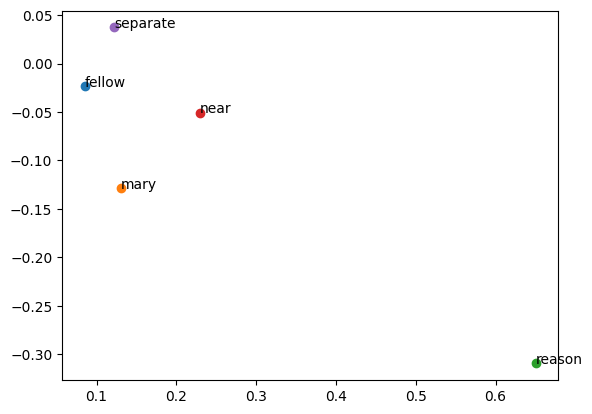

In [12]:
import matplotlib.pyplot as plt

print(f"W.shape: {W.shape}")

print(W)

np.random.seed(26)

plot_terms = []
for i in range(5):
    idx = np.random.randint(0, terms.size)
    plot_terms.append(terms[idx])
    print(terms[idx])


for etiqueta in plot_terms:
    filas = np.where(terms == etiqueta)[0]
    if filas.size == 0:
        print(f"'{etiqueta}' não está no vocabulário.")
        continue
    idx = int(filas[0])
    x, y = float(W[idx, 0]), float(W[idx, 1])
    print(f"{etiqueta}: idx={idx} -> ({x}, {y})")
    plt.scatter(x, y)
    plt.text(x, y, etiqueta)

#### **4.2 Similaridade entre termos:**
<font size=3>

- Calcule a [similaridade de cosseno](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) entre os pares de palavras ("love", "fly"), ("love", "run") e ("fly", "run").
  > **Dica:** Busque tais palavras no *array* de **vocabulário** usando a [`np.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html). Em seguinda, aplique a métrica à projeção $W_k$.

- **Escreva** em uma célula **markdown** sua interpretação dos valores dos resultados.


##### Calcular similaridade por cosseno e plot no espaço latente

cos(fly, love) = 0.89
cos(fly, run) = 0.86
cos(love, run) = 0.53


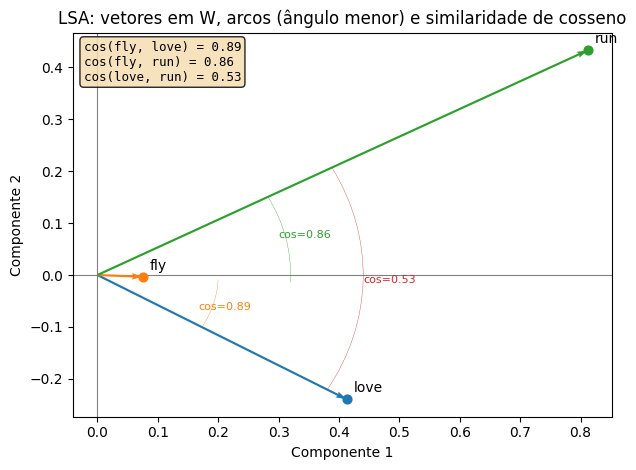

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def indice_termo(etiqueta):
    filas = np.where(terms == etiqueta)[0]
    return int(filas[0]) if filas.size > 0 else None


def angulos_arco_menor(t1, t2):
    """Ângulos em radianos para percorrer o arco menor entre duas direções (t crescente)."""
    a1 = (t1 + 2 * np.pi) % (2 * np.pi)
    a2 = (t2 + 2 * np.pi) % (2 * np.pi)
    d_ccw = (a2 - a1) % (2 * np.pi)
    if d_ccw <= np.pi:
        return a1, a1 + d_ccw
    d2 = (a1 - a2) % (2 * np.pi)
    return a2, a2 + d2


from matplotlib.patches import Arc
def montar_arco(ax, r, t0, t1, **plot_kw):
    """Arco de raio r centrado na origem, de t0 a t1 (radianos)."""
    # Converter radianos para graus
    theta1 = np.degrees(t0)
    theta2 = np.degrees(t1)
    
    # Arc usa graus e percorre no sentido anti-horário
    # Garantir ordem correta
    if theta2 < theta1:
        theta2 += 360

    arco = Arc(
        (0, 0),          # centro
        width=2*r,       # diâmetro no eixo x
        height=2*r,      # diâmetro no eixo y (círculo)
        angle=0,         # rotação da elipse
        theta1=theta1,   # ângulo inicial
        theta2=theta2,   # ângulo final
        **plot_kw
    )
    
    ax.add_patch(arco)

cfg_pares = [
    ("fly", "love"),
    ("fly", "run"),
    ("love", "run"),
    # ("facilities", "listen"),
    # ("facilities", "prices"),
    # ("listen", "prices"),
    # ("fly", "facilities")
]
termos_unicos = {x for a, b, *_ in cfg_pares for x in (a, b)}

indices = {t: indice_termo(t) for t in termos_unicos}
coords = {
    t: (float(W[i, 0]), float(W[i, 1]))
    for t, i in indices.items()
    if i is not None
}

# ajusta raio conforme escala dos pontos
r_ref = max(np.hypot(x, y) for x, y in coords.values()) if coords else 1.0
r_ref = 1.0
# Raios diferentes para separar os arcos visualmente
raios_pares = [
    (0.20 * r_ref, "C1"),
    (0.32 * r_ref, "C2"),
    (0.44 * r_ref, "C3"),
    # (0.20 * r_ref, "C3"),
    # (0.25 * r_ref, "C4"),
    # (0.40 * r_ref, "C5"),
    # (0.10 * r_ref, "C6"),
]

for t, i in indices.items():
    if i is None:
        print(f"'{t}' não está no vocabulário.")


fig, ax = plt.subplots()
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)

cores_pontos = {
    "love": "C0", 
    "fly": "C1", 
    "run": "C2",
#    "facilities": "C0",
#    "listen": "C1",
#    "prices": "C2",
}

for t, (x, y) in coords.items():
    c = cores_pontos.get(t, "C3")
    ax.quiver(
        0,
        0,
        x,
        y,
        angles="xy",
        scale_units="xy",
        scale=1,
        color=c,
        width=0.004,
        zorder=2,
    )
    ax.scatter([x], [y], color=c, s=40, zorder=3)
    ax.annotate(t, (x, y), xytext=(5, 5), textcoords="offset points")

linhas_cos = []
for (a, b), (raio_arc, cor_arc) in zip(cfg_pares, raios_pares): # parear as tuplas e extrair os valores
    if indices[a] is None or indices[b] is None:
        print(f"Par ({a}, {b}): ignorado (termo em falta).")
        continue
    ia, ib = indices[a], indices[b]
    cos = float(cosine_similarity([W[ia]], [W[ib]])[0, 0])
    print(f"cos({a}, {b}) = {cos:.2f}")
    linhas_cos.append(f"cos({a}, {b}) = {cos:.2f}")
    xa, ya = coords[a]
    xb, yb = coords[b]
    ta = np.arctan2(ya, xa)
    tb = np.arctan2(yb, xb)
    t0, t1 = angulos_arco_menor(ta, tb)
    montar_arco(
        ax, raio_arc, t0, t1, color=cor_arc, lw=0.25, zorder=4, linestyle="-"
    )
    t_mid = t0 + (t1 - t0) / 2
    r_txt = raio_arc * 1.10
    ax.text(
        r_txt * np.cos(t_mid),
        r_txt * np.sin(t_mid),
        f"cos={cos:.2f}",
        fontsize=8,
        ha="center",
        va="center",
        color=cor_arc,
    )

if linhas_cos:
    ax.text(
        0.02,
        0.98,
        "\n".join(linhas_cos),
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        family="monospace",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.85),
    )

ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_title("LSA: vetores em W, arcos (ângulo menor) e similaridade de cosseno")

plt.tight_layout()


##### Interpretação da similaridade por cosseno dos tres pares

A interpretação a partir dos valores de similaridade por cosseno nos permite dizer que os pares fly/love e fly/run estão praticamente equidistantes em termos de angulos, com significado semantico bem mais proximos por exemplo que entre o par love/run. Quando analisamos o grafico podemos visualizar tal analise. O grafico dos vetores semanticos das tres palavras mostram uma certa equidistancia angular entre esses dois pares mencionados. 

Em linhas gerais, quanto mais proximo de 1 o cosseno do angulo formado pelos dois vetores, mais similaridade entre as palavras. Quando mais proximo de zero a similaridade é neutra, e quanto mais proximo de -1 a similaridade é oposta, ou seja, são opostos semanticamente. Isso graficamente se traduz em vetores mais proximos ou mais afastados em relação as direções entre ambos.

Podemos dizer então que existe uma similaridade semantica praticamente equivalente entre fly/love e entre fly/run. Porém essa similaridade diminui entre run/love.